# Expansion Analysis

This notebook compares materialized synthetic expansion analyses for pre-electrification, optimized post-electrification, and fixed no-flex post-electrification cases. It shows synthetic-only power-flow stress based on compact summary tables and maps expansion cost envelopes per supplied synthetic grid area.


In [1]:
AGS = "9474126"  # Munich:"09162000", Forchheim:"9474126"
BASE_ANALYSIS_SUFFIX = "full_year_post_electrification_hh_only_tsam"

In [2]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv


def find_postprocessing_dir() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "plotting").is_dir() and (candidate / "expansion").is_dir():
            return candidate
    raise FileNotFoundError("Could not find GridExpand/5.postprocessing from the notebook working directory.")


POSTPROCESSING_DIR = find_postprocessing_dir()
load_dotenv(POSTPROCESSING_DIR.parent / ".env", override=False)
if str(POSTPROCESSING_DIR) not in sys.path:
    sys.path.insert(0, str(POSTPROCESSING_DIR))

from expansion.notebook_workflow import (
    analysis_prefix_from_ags,
    display_label_from_ags,
    expansion_cost_comparison_from_tables,
    expansion_cost_reduction_summary,
    load_expansion_stage_context,
    load_powerflow_cutoff_comparison,
    load_transformer_import_distributions_for_analysis,
    load_voltage_summaries_for_powerflow_comparison,
    normalize_ags_string,
    output_slug_from_ags,
)
from plotting import geoplotting
from plotting.expansion_cost_plots import plot_expansion_cost_comparison_bar
from plotting.powerflow_asset_plots import plot_powerflow_asset_cutoff_overview_static
from plotting.powerflow_io import save_plotly_figure
from plotting.powerflow_transformer import plot_transformer_import_distributions_matplotlib
from plotting.powerflow_voltage import plot_voltage_deviation_histogram_comparison

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

In [3]:
DISPLAY_LABEL = display_label_from_ags(AGS)
ANALYSIS_PREFIX = analysis_prefix_from_ags(AGS, BASE_ANALYSIS_SUFFIX)
STAGE_LABELS = {
    "pre": "status-quo",
    "post_no_flex": "100-electrification-no-flex",
    "post_flex": "100-electrification-HEMS",
}
ANALYSIS_KEYS = {
    STAGE_LABELS["pre"]: f"{ANALYSIS_PREFIX}_pre",
    STAGE_LABELS["post_no_flex"]: f"{ANALYSIS_PREFIX}_post_no_flex",
    STAGE_LABELS["post_flex"]: f"{ANALYSIS_PREFIX}_post",
}

DEFAULT_ANALYSIS_LABEL = STAGE_LABELS["post_flex"]
ANALYSIS_KEY = ANALYSIS_KEYS[DEFAULT_ANALYSIS_LABEL]

SYNTHETIC_POWERFLOW_SUMMARY_SPECS = {
    STAGE_LABELS["pre"]: {"run_name": "baseline_static_hh_only_post_electrification_summary_powerflow", "stage": "pre"},
    STAGE_LABELS["post_no_flex"]: {"run_name": "baseline_static_hh_only_post_electrification_summary_no_flex_powerflow", "stage": "post"},
    STAGE_LABELS["post_flex"]: {"run_name": "baseline_static_hh_only_post_electrification_summary_powerflow", "stage": "post"},
}
REAL_POWERFLOW_SUMMARY_SPECS = {
    STAGE_LABELS["pre"]: {"run_name": "real_swf_2045_full_local_sector_flex", "stage": "pre"},
    STAGE_LABELS["post_no_flex"]: {"run_name": "real_swf_2045_full_local_sector_no_flex", "stage": "post"},
    STAGE_LABELS["post_flex"]: {"run_name": "real_swf_2045_full_local_sector_flex", "stage": "post"},
}

COMPARISON_COLORS = {
    STAGE_LABELS["pre"]: "#2E7D32",
    STAGE_LABELS["post_no_flex"]: "#D62728",
    STAGE_LABELS["post_flex"]: "#1F77B4",
}
SOURCE_STYLE_MAP = {
    "Synthetic": {"linestyle": "-", "offset": -0.18, "alpha": 0.26, "marker_alpha": 0.42},
    "Real SWF": {"linestyle": "--", "dashes": (3.0, 2.0), "offset": 0.18, "alpha": 0.18, "marker_alpha": 0.48},
}

PLZ = None
SCENARIO_ID = None
ASSET_CUTOFF_PERCENTILE = 1.0
SHOW_BUILDING_POINTS = False
SHOW_ENVELOPE_AXIS_TICKS = False
REAL_GRID_DATA_PATH = os.getenv("GRID_DATA_PATH", "/home/breveron/data/swf_split_hybrid")
OUTPUT_DIR = POSTPROCESSING_DIR / "plotting" / "output" / "expansion" / output_slug_from_ags(AGS)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Selected region: {DISPLAY_LABEL} [AGS {normalize_ags_string(AGS)}]")
print(f"Using analysis prefix: {ANALYSIS_PREFIX}")

Selected region: Forchheim (Stadt) [AGS 09474126]
Using analysis prefix: full_year_post_electrification_hh_only_tsam


## Load Expansion Analysis

The materialized expansion analysis is loaded once here and reused by the following plots. Summary tables are collected at the bottom of the notebook so the visual analysis comes first.


In [4]:
analysis_context = load_expansion_stage_context(
    ANALYSIS_KEYS,
    default_analysis_label=DEFAULT_ANALYSIS_LABEL,
)

expansion_tables_by_stage = analysis_context["expansion_tables_by_stage"]
analysis_meta_by_stage = analysis_context["analysis_meta_by_stage"]
available_analysis_keys = analysis_context["available_analysis_keys"]
missing_analysis_keys = analysis_context["missing_analysis_keys"]
DEFAULT_ANALYSIS_LABEL = analysis_context["default_analysis_label"]
expansion_tables = analysis_context["expansion_tables"]
analysis_key = analysis_context["analysis_key"]
ANALYSIS_KEY = analysis_key

if missing_analysis_keys:
    print("Missing materialized expansion analyses; plots below use available analyses only:")
    for label, key in missing_analysis_keys.items():
        print(f"  - {label}: {key}")
print(f"Default summary tables use: {DEFAULT_ANALYSIS_LABEL} ({analysis_key})")

analysis_context["analysis_status"]

Default summary tables use: 100-electrification-HEMS (full_year_post_electrification_hh_only_tsam_post)


,stage_label,analysis_key,available,run_name,stage,grids_with_expansion_summary,total_cost_eur
0,status-quo,full_year_post_electrification_hh_only_tsam_pre,True,baseline_static_hh_only_post_electrification_s...,pre,74,0.000000e+00
1,100-electrification-no-flex,full_year_post_electrification_hh_only_tsam_po...,True,baseline_static_hh_only_post_electrification_s...,post,74,6.841195e+06
2,100-electrification-HEMS,full_year_post_electrification_hh_only_tsam_post,True,baseline_static_hh_only_post_electrification_s...,post,73,4.237266e+06


## Expansion Cost Comparison

This plot compares materialized heuristic expansion costs, split into cable and transformer costs. Synthetic costs are available from the current expansion materialization. Real SWF costs are shown only if a corresponding real expansion-cost materialization exists; otherwise the notebook reports that they are missing.


No materialized real SWF expansion-cost analysis found; the cost bar currently shows synthetic costs only.


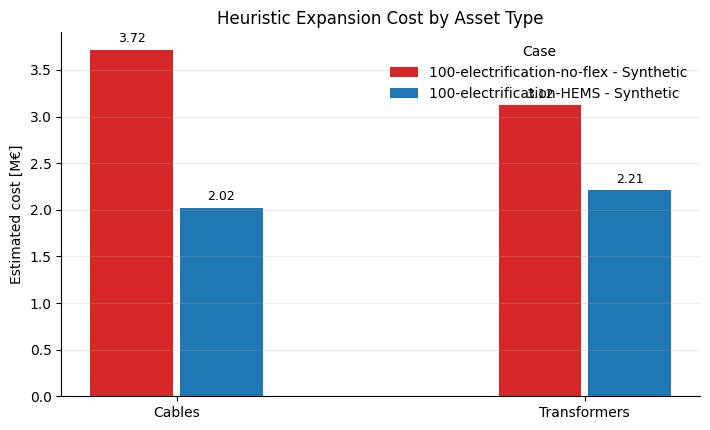

,stage,data_source,component,cost_eur
0,100-electrification-no-flex,Synthetic,Cables,3.717195e+06
1,100-electrification-no-flex,Synthetic,Transformers,3.124000e+06
2,100-electrification-HEMS,Synthetic,Cables,2.023266e+06
3,100-electrification-HEMS,Synthetic,Transformers,2.214000e+06


In [5]:
expansion_cost_comparison = expansion_cost_comparison_from_tables(
    expansion_tables_by_stage,
    analysis_meta_by_stage,
    post_no_flex_label=STAGE_LABELS["post_no_flex"],
    post_flex_label=STAGE_LABELS["post_flex"],
    data_source="Synthetic",
)
if "Real SWF" not in set(expansion_cost_comparison.get("data_source", pd.Series(dtype=str)).astype(str)):
    print("No materialized real SWF expansion-cost analysis found; the cost bar currently shows synthetic costs only.")
plot_expansion_cost_comparison_bar(
    expansion_cost_comparison,
    stage_order=(STAGE_LABELS["post_no_flex"], STAGE_LABELS["post_flex"]),
    color_map=COMPARISON_COLORS,
    output_path=OUTPUT_DIR / "post_flex_no_flex_expansion_cost_bar",
)
expansion_cost_comparison

In [6]:
cost_reduction_summary = expansion_cost_reduction_summary(
    expansion_cost_comparison,
    post_no_flex_label=STAGE_LABELS["post_no_flex"],
    post_flex_label=STAGE_LABELS["post_flex"],
)
if cost_reduction_summary.empty:
    print("No complete post-electrification cost summaries available for reduction calculation.")
cost_reduction_summary

,component,no_flex_cost_million_eur,flex_cost_million_eur,saving_million_eur,reduction_percent
0,Cables,3.72,2.02,1.69,45.6
1,Transformers,3.12,2.21,0.91,29.1
2,Total,6.84,4.24,2.60,38.1


## Synthetic and Real Power-Flow Stress Overview

This reuses the retained-asset cutoff plot from the power-flow comparison workflow. Synthetic and real SWF results are shown in the same panels when available: stage colors are shared, synthetic curves are solid, and real SWF curves are dashed. The real SWF batch can be inspected while it is still running; the coverage table below shows how many real grids are already included.


,data_source,comparison_stage,grids
0,Real SWF,status-quo,71
3,Synthetic,status-quo,74
1,Real SWF,100-electrification-no-flex,70
4,Synthetic,100-electrification-no-flex,74
2,Real SWF,100-electrification-HEMS,71
5,Synthetic,100-electrification-HEMS,73


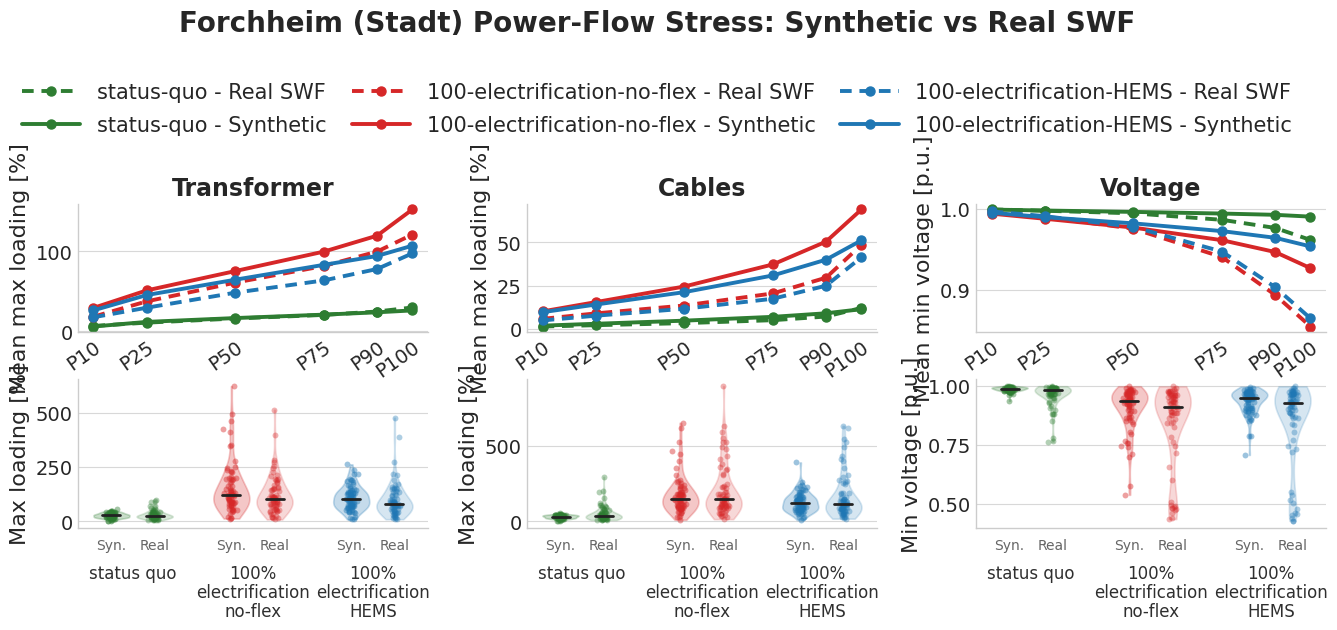

In [7]:
powerflow_comparison = load_powerflow_cutoff_comparison(
    synthetic_specs=SYNTHETIC_POWERFLOW_SUMMARY_SPECS,
    real_specs=REAL_POWERFLOW_SUMMARY_SPECS,
    stage_order=list(STAGE_LABELS.values()),
    ags=AGS,
    scenario_id=SCENARIO_ID,
    plz=PLZ,
)
powerflow_profile = powerflow_comparison["profile"]
synthetic_summary = powerflow_comparison["asset_summary"]
coverage_summary = powerflow_comparison["coverage_summary"]
display(coverage_summary)

plotted_stages = [stage for stage in STAGE_LABELS.values() if stage in set(powerflow_profile["comparison_stage"].dropna())]
fig = plot_powerflow_asset_cutoff_overview_static(
    powerflow_profile,
    group_col="comparison_stage",
    source_col="data_source",
    source_style_map=SOURCE_STYLE_MAP,
    color_map={label: COMPARISON_COLORS[label] for label in plotted_stages if label in COMPARISON_COLORS},
    asset_cutoff_percentile=ASSET_CUTOFF_PERCENTILE,
    asset_percentiles=(0.10, 0.25, 0.50, 0.75, 0.90, 1.0),
    worst_asset_per_grid=True,
    title=f"{DISPLAY_LABEL} Power-Flow Stress: Synthetic vs Real SWF",
    save_path=OUTPUT_DIR / "pre_post_flex_no_flex_synthetic_real_asset_cutoff_overview",
)
plt.show()

for source, skipped in powerflow_comparison["skipped"].items():
    if skipped:
        print(f"Skipped missing {source} compact power-flow summaries:")
        for label, reason in skipped.items():
            print(f"  - {label}: {reason}")

## Synthetic Raw Weekly Power-Flow Diagnostics

These plots use transformer-import diagnostics from synthetic compact/raw power-flow output. The current real SWF compact schema stores scalar transformer loading summaries, but not the transformer import time-series/diagnostic curves required by `plot_transformer_import_distributions_matplotlib`; the combined synthetic/real transformer comparison is therefore provided in the retained-asset cutoff overview above.


In [8]:
voltage_summaries = load_voltage_summaries_for_powerflow_comparison(
    synthetic_analysis_meta_by_stage=analysis_meta_by_stage,
    real_specs=REAL_POWERFLOW_SUMMARY_SPECS,
    real_plz=91301 if normalize_ags_string(AGS) == "09474126" else PLZ,
)
voltage_fig = plot_voltage_deviation_histogram_comparison(
    voltage_summaries,
    lower_limit=0.95,
    upper_limit=1.03,
    show=False,
)
try:
    save_plotly_figure(
        voltage_fig,
        OUTPUT_DIR / "pre_post_flex_no_flex_voltage_deviation_histogram",
        formats=("svg", "png"),
        width=1370,
        height=720,
    )
except RuntimeError as exc:
    print(f"Could not export voltage histogram: {exc}")
display(voltage_fig)


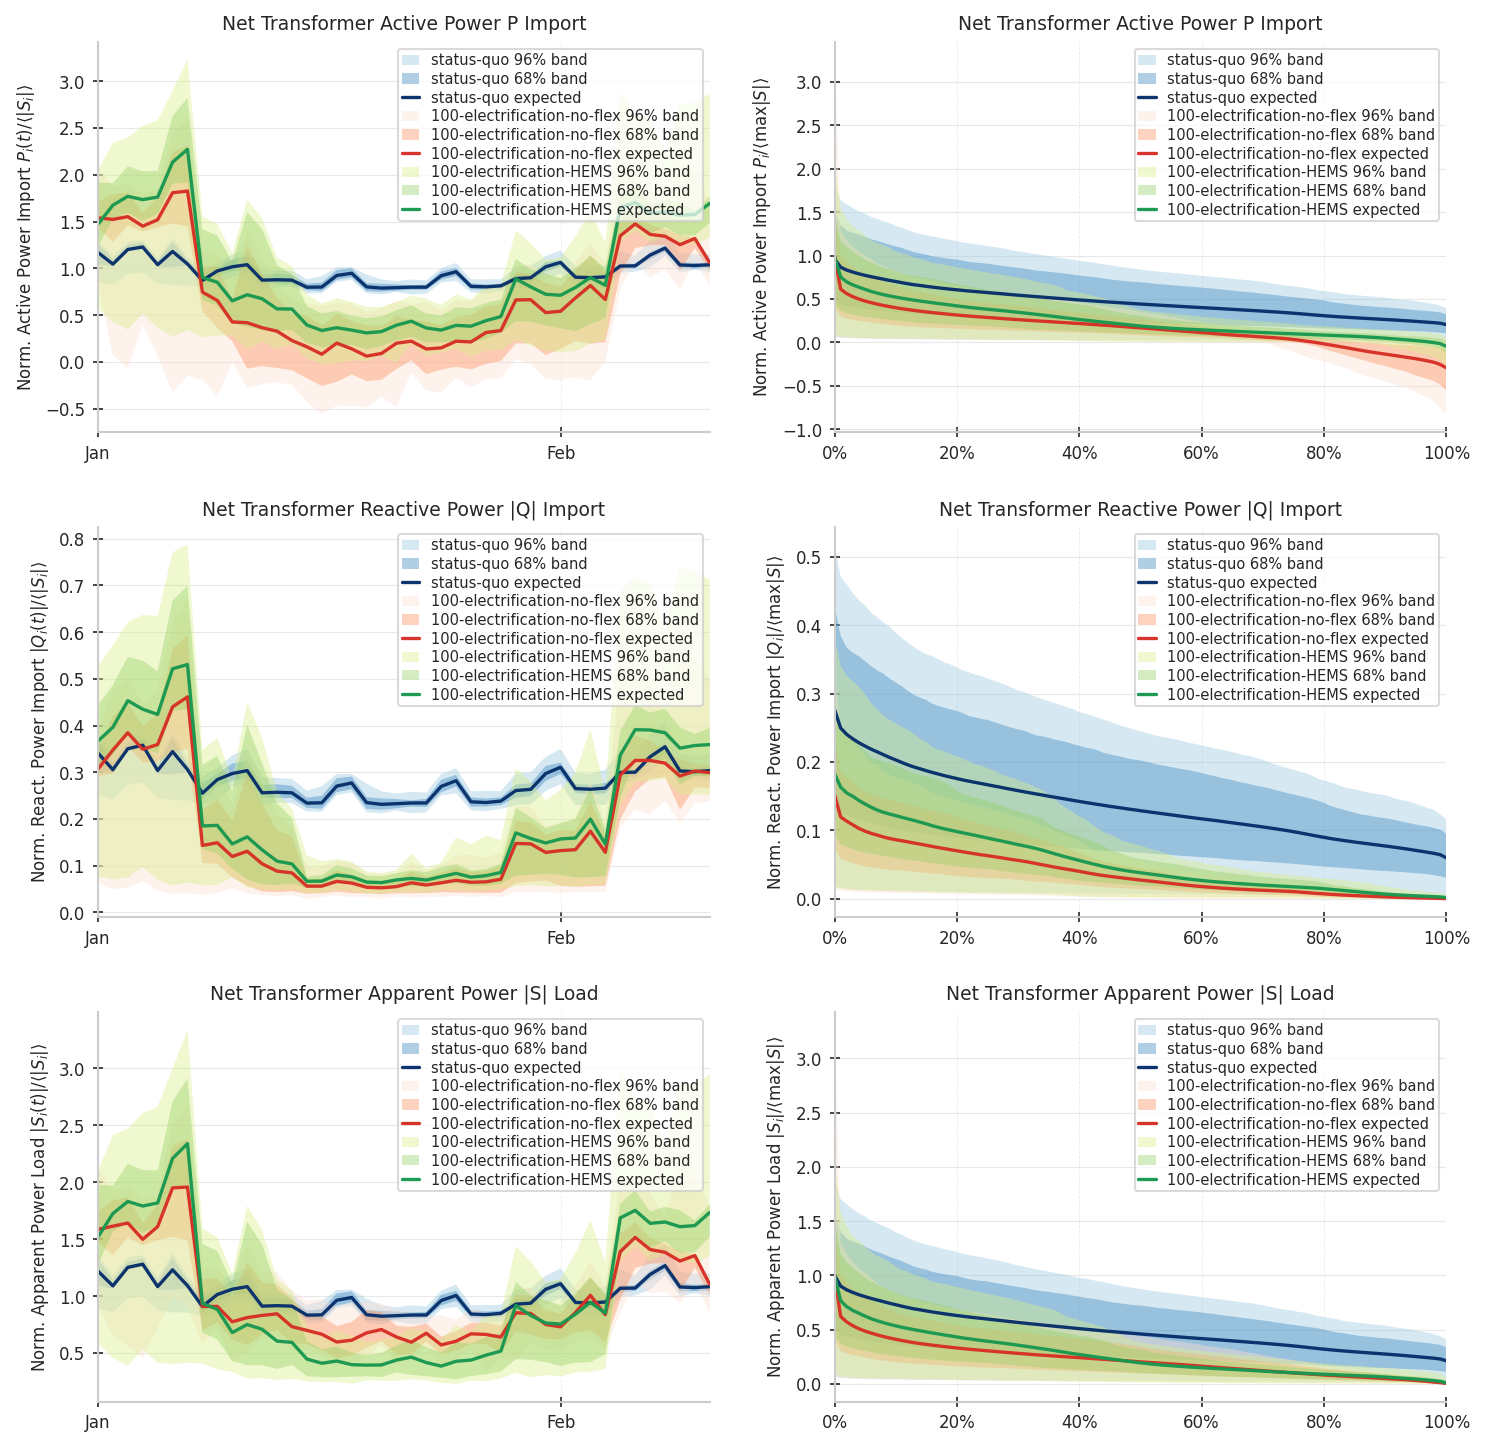

In [9]:
transformer_distribution = load_transformer_import_distributions_for_analysis(analysis_meta_by_stage)
if transformer_distribution.empty:
    print("No available expansion analyses for transformer diagnostics.")
else:
    transformer_fig = plot_transformer_import_distributions_matplotlib(
        transformer_distribution,
        metrics=("p", "q", "s"),
        group_col="comparison_stage",
        tsam_week_panels=False,
        show=False,
    )
    transformer_fig.savefig(
        OUTPUT_DIR / "pre_post_flex_no_flex_transformer_import_distributions.svg",
        bbox_inches="tight",
    )
    plt.show()

## Expansion Cost Envelopes

The envelope maps aggregate building/bus points to the supplied synthetic grid areas and color each envelope by the materialized expansion cost. Values are clipped at the selected quantile so one very expensive grid does not dominate the color scale.


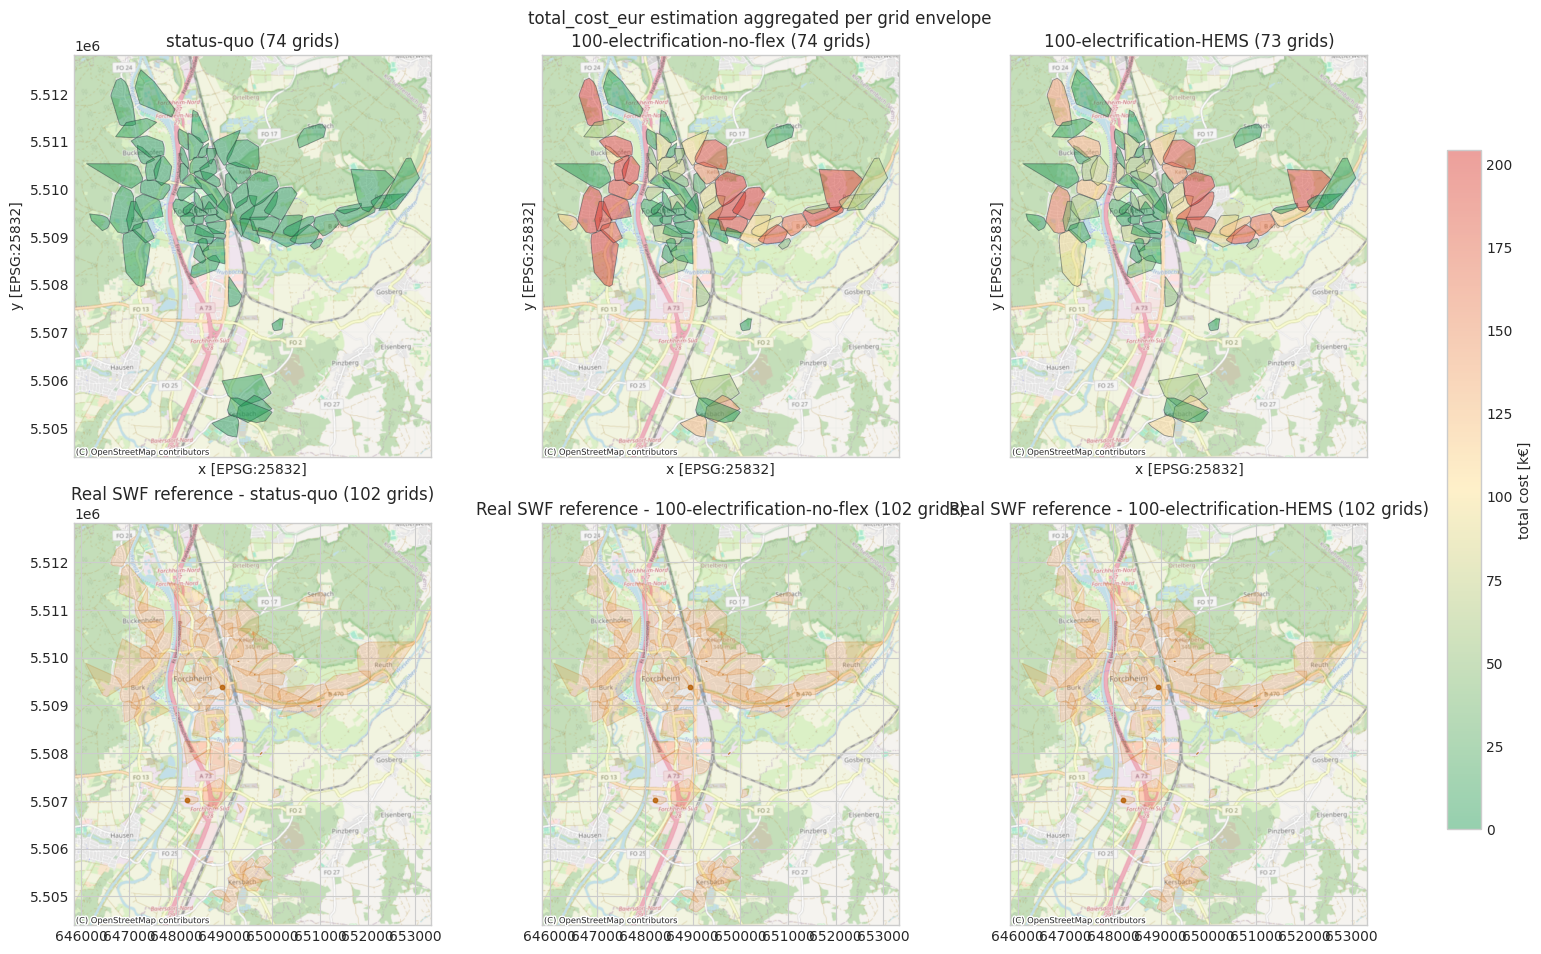

In [10]:
BUILDING_POINT_SIZE = 1.2
BUILDING_POINT_ALPHA = 0.06
fig, axes, total_envelope_data = geoplotting.plot_synthetic_expansion_envelope_panels(
    analysis_keys=available_analysis_keys,
    value_column="total_cost_eur",  # transformer_cost_eur, cable_cost_eur, total_cost_eur
    clip_quantile=0.95,
    log_scale=False,
    cmap="cost_green_red",
    show_buildings=SHOW_BUILDING_POINTS,
    building_point_size=BUILDING_POINT_SIZE,
    building_alpha=BUILDING_POINT_ALPHA,
    ncols=3,
    real_grid_data_path=REAL_GRID_DATA_PATH,
    real_load_type="HH",
    output_path=OUTPUT_DIR / "pre_post_flex_no_flex_total_cost_envelopes.svg",
)
plt.show()


## Summary Tables

Compact table outputs for the materialized expansion analysis and the plotted diagnostics.


In [11]:
expansion_tables["analysis_run"]


,expansion_analysis_run_id,analysis_key,assumption_key,run_name,stage,scenario_id,ags,plz,created_at,note
0,16,full_year_post_electrification_hh_only_tsam_post,de_lv_heuristic_2026,baseline_static_hh_only_post_electrification_s...,post,None,9474126,None,2026-07-10 10:53:12.803130+00:00,


In [12]:
expansion_tables["cost_summary"]


,grids_with_line_rows,cable_segments,cable_segments_requiring_expansion,cable_segments_overloaded,cable_cost_eur,transformers,transformers_requiring_expansion,transformers_overloaded,transformer_cost_eur,total_cost_eur
0,73,1078,191,191,2.023266e+06,73,39,39,2214000.0,4.237266e+06


In [13]:
expansion_tables["grid_cost_summary"].head(10)


,grid_case_id,plz,kcid,bcid,cable_segments,cable_segments_requiring_expansion,cable_cost_eur,max_cable_loading_percent,transformer_rated_power_kva,required_transformer_kva,additional_transformer_kva,transformer_requires_expansion,transformer_cost_eur,transformer_loading_percent,total_cost_eur
0,1894,91301,10,5,26,9,211864.992001,389.285743,630.0,1700.0,1070.0,True,100000.0,262.019141,311864.992001
1,1890,91301,10,4,16,7,97994.316201,234.923983,630.0,1200.0,570.0,True,100000.0,188.768414,197994.316201
2,1686,91301,3,3,41,11,97149.137393,241.676934,630.0,1150.0,520.0,True,100000.0,179.402214,197149.137393
3,1918,91301,11,3,15,5,90308.480989,259.305659,630.0,1100.0,470.0,True,100000.0,171.907671,190308.480989
4,1838,91301,7,12,25,8,89263.222160,228.510951,630.0,1400.0,770.0,True,100000.0,218.989036,189263.222160
5,1898,91301,10,6,20,8,85835.407790,175.816929,630.0,1250.0,620.0,True,100000.0,191.294648,185835.407790
6,1930,91301,11,6,20,7,71992.328995,163.143851,630.0,1200.0,570.0,True,100000.0,186.650999,171992.328995
7,1858,91301,9,5,41,7,66220.507300,152.099762,630.0,1050.0,420.0,True,100000.0,160.798652,166220.507300
8,1834,91301,7,11,18,4,48469.579016,221.213714,630.0,1100.0,470.0,True,100000.0,168.243639,148469.579016
9,1842,91301,8,1,27,8,96596.587286,139.435932,630.0,850.0,220.0,True,48000.0,130.928928,144596.587286


In [14]:
expansion_tables["cable_summary_by_type"]


,visible_std_type,cable_segments,cable_segments_requiring_expansion,length_km,estimated_cost_eur,max_loading_percent
0,NAYY_4_120,943,130,117.626987,1.216613e+06,259.305659
1,NAYY_4_185,41,20,7.222127,2.978979e+05,255.179296
2,NAYY_4_240,35,14,8.725668,2.224372e+05,389.285743
3,NAYY_4_300,28,13,7.316232,1.832549e+05,211.447832
4,NAYY_4_150,30,14,4.377877,1.030629e+05,241.676934
5,NAYY_4_50,1,0,0.017310,0.000000e+00,73.928001


In [15]:
expansion_tables["transformer_summary_by_basis"]


,transformer_cost_basis,transformers,transformers_requiring_expansion,additional_transformer_kva,estimated_cost_eur,max_loading_percent
0,station_rebuild_boundary_case_gt_1000kva,9,9,5480.0,900000.0,262.019141
1,all_in_replacement_to_1000kva,13,13,3970.0,624000.0,234.318044
2,all_in_replacement_to_800kva,11,11,1250.0,462000.0,193.392716
3,all_in_replacement_to_630kva,6,6,650.0,228000.0,134.721386
4,none_existing_capacity_sufficient,34,0,0.0,0.0,95.594136


### Power-Flow Stress Input Coverage


In [16]:
synthetic_summary


,data_source,comparison_stage,metric,asset_type,assets,grids
0,Real SWF,status-quo,Cables,cable,42780,71
1,Real SWF,status-quo,Transformer,transformer,355,71
2,Real SWF,status-quo,Voltage,bus,32320,71
9,Synthetic,status-quo,Cables,cable,41120,74
10,Synthetic,status-quo,Transformer,transformer,370,74
11,Synthetic,status-quo,Voltage,bus,30635,74
3,Real SWF,100-electrification-no-flex,Cables,cable,42675,70
4,Real SWF,100-electrification-no-flex,Transformer,transformer,350,70
5,Real SWF,100-electrification-no-flex,Voltage,bus,32245,70
12,Synthetic,100-electrification-no-flex,Cables,cable,41120,74


### Voltage Summary Sample


In [17]:

if "voltage_summaries" in globals() and voltage_summaries:
    voltage_summary = pd.concat(voltage_summaries.values(), ignore_index=True)
    display(voltage_summary[["grid", "stage", "n_timesteps", "n_buses", "min_vm_pu", "max_vm_pu"]].head())
else:
    print("Run the voltage diagnostics cell first.")


TypeError: cannot concatenate object of type '<class 'dict'>'; only Series and DataFrame objs are valid

### Envelope Cost Ranking Sample


In [ ]:

if "total_envelope_data" in globals():
    display(total_envelope_data["grid_metrics"].head(5))
else:
    print("Run the expansion cost envelope cell first.")
